In [14]:
import torch
import torch.nn as nn
from Settings import TinyStoriesLM
from datetime import datetime
import random
import matplotlib.pyplot as plt


from tokenizer import TinyStoriesTokenizer
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass, asdict
import numpy as np

print("cell ran")

cell ran


In [2]:
# ============= Hyper-parameters for training ============== #

@dataclass
class Config :
    vocab_size: int = 5000  # This number should agree with the tokenizer
    number_of_transformer_blocks: int = 4
    number_of_attention_heads: int = 1
    vector_dim: int = 256
    block_size: int = 512
    dropout_prob: float = 0.1
    batch_size: int = 8
    learning_rate: float = 0.0005
    weight_decay: float = 0.000001
    no_of_epochs: int = 1


class TinyStoriesDataset(Dataset):
    def __init__(self, data_file, block_size):
        """
        data_file: path to the .bin file (uint16 array of token IDs)
        block_size: the context window (e.g., 256 or 512 tokens)
        """

        # Memory-map the data file (RAM usage stays near zero!)
        self.data = np.memmap(data_file, dtype=np.uint16, mode='r')
        self.block_size = block_size

    def __len__(self):
        # We subtract block_size to ensure we don't go out of bounds
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        # Pull a chunk of length block_size + 1 (data and target)
        chunk = self.data[idx : idx + self.block_size + 1]

        # Convert to torch tensors
        x = torch.from_numpy(chunk[:-1].astype(np.int64)) # Input
        y = torch.from_numpy(chunk[1:].astype(np.int64))  # Target (shifted by 1)

        return x, y 


class ProbeDataset(Dataset):
    def __init__(self, data, tensor_tags, index_range, limit=512, ignore_index = -100):
        self.data = data
        self.limit = limit
        self.index_range = list(index_range)
        self.tensor_tags = tensor_tags
        self.ignore_index = ignore_index
        #self.pos_to_id = pos_to_id

    def __len__(self):
        return len(self.index_range)

    def __getitem__(self, idx):
        idx_true = self.index_range[idx]
    
        # when we built tensors, we bactch (0, 512, 1024, 1536...)
        # To get the real position
        dataset_index = idx_true * self.limit

        # Extract binary file
        item = self.data[dataset_index]
        input_ids = item[0][:self.limit] 
        
        # from tensor tags
        labels = self.tensor_tags[idx_true][:self.limit].clone()
        labels[labels < 3] = self.ignore_index
        
        return {
            'input_ids': input_ids,
            'labels': labels
        }

print("probedataset ready")

probedataset ready


In [3]:
# We load the aligned data
tensores_tags_dataset = torch.load('tags_probes_5k_first_subtoken.pt')
POS_TAGS_VOCAB = [
    'PAD', 'SUBWORD', 'X', 'ADJ', 'ADP', 'ADV', 'AUX', 'CONJ', 
    'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 
    'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB'
]
tag2id = {tag: idx for idx, tag in enumerate(POS_TAGS_VOCAB)}
id2tag = {idx: tag for tag, idx in tag2id.items()}
ignore_index = -100
print(f"{len(tensores_tags_dataset)} tensors for Probing.")

5000 tensors for Probing.


In [4]:
import json

with open("multipos_dict.json", "r") as f:
    multipos_dict = json.load(f)

print("cell ran")

cell ran


In [5]:
#alto


In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint_path = 'last_checkpoint_next_word.pt'

model = TinyStoriesLM.load(checkpoint_path, device=device).to(device)
training_dataset = TinyStoriesDataset('/datasets/dd2417/train.bin', Config.block_size)
tokenizer = TinyStoriesTokenizer.load('/datasets/dd2417/tokenizer.json')

# We have to freeze all the model
for param in model.parameters():
    param.requires_grad = False

# We set our model i eval mode -> deactivate dropout  so the vectors are stable
# dropout turns off random neurons during training to avoid overfitting/memorizing 
model.eval() #same input = same output

activations = {}

def forward_hook(module, input, output): # hook function
    # 'output' - ouput from Transformer layer
    # module layer that was just executed
    # save in our dictionary
    # .detach() no gradient info / history - we just want numbers
    
    if isinstance(output, tuple):
        activations[module.name] = output[0].detach()
    else:
        activations[module.name] = output.detach()

hooks = []

# register each block (TransformerBlock)
for i, block in enumerate(model.transformers):
    block.name = f"layer_{i}" 
    handle = block.register_forward_hook(forward_hook)
    hooks.append(handle)


num_tags = len(tag2id)
input_dim = model.config.vector_dim
limit = model.config.block_size
num_layers = len(model.transformers)

# from 5,000 stories -> 4500 train and 500 validate
# data for training
train_subset_tags = tensores_tags_dataset[:4500]
val_subset_tags = tensores_tags_dataset[4500:]

# index_range to ensure aligment
train_ds = ProbeDataset(training_dataset, tensores_tags_dataset, index_range=range(0, 4500), limit=limit)
train_loader = DataLoader(train_ds, batch_size=model.config.batch_size, shuffle=True)

val_ds = ProbeDataset(training_dataset, tensores_tags_dataset, index_range=range(4500, 5000), limit=limit)
val_loader = DataLoader(val_ds, batch_size=model.config.batch_size, shuffle=False)


Model loaded from last_checkpoint_next_word.pt (Epoch 0, iteration 130000)


In [7]:
print(f"Subsets : training: {len(train_ds)} | validation: {len(val_ds)}")

target_words = [' so',' playing' ,' back', ' it', ' he']
evolution_tracking = {word: {} for word in target_words}


# FOR GRAPHS
all_general_acc = []
all_ambiguous_acc = []

# Layer for layer
for layer_to_probe in range(num_layers):
    layer_name = f"layer_{layer_to_probe}"
    print(f"\nTraining probe of: {layer_name}")

    probe = nn.Linear(input_dim, num_tags).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)

    # Training
    for epoch in range(3):
        probe.train()
        for batch in train_loader:
            activations.clear()
            ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                model(ids) 

            optimizer.zero_grad()
            logits = probe(activations[layer_name])
   
            loss = criterion(logits.view(-1, num_tags), labels.view(-1))
            loss.backward()
            optimizer.step()

        # Evaluation
        probe.eval()
        correct_tokens = 0
        total_tokens = 0
        correct_ambiguous_tokens = 0
        total_ambiguous_tokens = 0
        
        with torch.no_grad():
            for v_batch in val_loader:
                v_ids = v_batch['input_ids'].to(device)
                v_labels = v_batch['labels'].to(device)
                
                model(v_ids)
                v_logits = probe(activations[layer_name])
                predictions = v_logits.argmax(dim=-1)

                v_probs = torch.softmax(v_logits, dim=-1)
                top_3_probs, top_3_idx = torch.topk(v_probs, k=3, dim=-1)  

                for b in range(v_ids.size(0)):
                    ids_list = v_ids[b].tolist()
                    tokens = tokenizer.decode_to_tokens(ids_list)
                    
                    for t in range(len(tokens)):
                        label_real = v_labels[b, t].item()
                        if label_real == ignore_index:
                            continue 
                        
                        current_word = tokens[t] 
    
                        # just last epoch
                        if epoch == 2 and current_word in target_words:
                            inicio_contexto = max(0, t - 5)
                            fin_contexto = min(len(ids_list), t + 5)
                            texto_antes = tokenizer.decode(ids_list[inicio_contexto: t])
                            frase_id = f"{texto_antes} *[{current_word.upper().strip()}]*"

                            if frase_id not in evolution_tracking[current_word]:
                                evolution_tracking[current_word][frase_id] = {}
                            
                            pred_label = predictions[b, t].item()
                            top_3_lista = top_3_idx[b, t].tolist()
                            top_3_tags = [id2tag[idx] for idx in top_3_lista]
                            top_3_probs_list = top_3_probs[b, t].tolist()
                            percentages = [p * 100 for p in top_3_probs_list]
                                
                            evolution_tracking[current_word][frase_id][layer_name] = {
                                "real_tag": id2tag[label_real],
                                "pred_tag": id2tag[pred_label],
                                "top_3_tags": top_3_tags,
                                "percentages": percentages
                            }
                                
                        # general metrics for multipos, always
                        if current_word in multipos_dict:
                            pred_label = predictions[b, t].item()
                            total_ambiguous_tokens += 1
                            if pred_label == label_real:
                                correct_ambiguous_tokens += 1
                
                # global epoch
                mask = (v_labels != ignore_index)
                correct_tokens += (predictions[mask] == v_labels[mask]).sum().item()
                total_tokens += mask.sum().item()
                    
        epoch_accuracy = (correct_tokens / total_tokens) * 100 if total_tokens > 0 else 0.0
        epoch_ambiguity_accuracy = (correct_ambiguous_tokens / total_ambiguous_tokens) * 100 if total_ambiguous_tokens > 0 else 0.0        
        print(f"Epoch {epoch + 1} accuracy: {epoch_accuracy:.2f}% | Ambiguous Accuracy: {epoch_ambiguity_accuracy:.2f}%")
               
    all_general_acc.append(epoch_accuracy)
    all_ambiguous_acc.append(epoch_ambiguity_accuracy)
    print(f"="*70) 
for handle in hooks:
    handle.remove()

# when training (ignore_index=-100) impo
print("cell ran")

Subsets : training: 4500 | validation: 500

Training probe of: layer_0
Epoch 1 accuracy: 96.11% | Ambiguous Accuracy: 94.67%
Epoch 2 accuracy: 96.56% | Ambiguous Accuracy: 95.23%
Epoch 3 accuracy: 96.73% | Ambiguous Accuracy: 95.46%

Training probe of: layer_1
Epoch 1 accuracy: 97.12% | Ambiguous Accuracy: 96.11%
Epoch 2 accuracy: 97.34% | Ambiguous Accuracy: 96.39%
Epoch 3 accuracy: 97.45% | Ambiguous Accuracy: 96.50%

Training probe of: layer_2
Epoch 1 accuracy: 97.37% | Ambiguous Accuracy: 96.58%
Epoch 2 accuracy: 97.64% | Ambiguous Accuracy: 96.87%
Epoch 3 accuracy: 97.70% | Ambiguous Accuracy: 96.95%

Training probe of: layer_3
Epoch 1 accuracy: 96.95% | Ambiguous Accuracy: 96.25%
Epoch 2 accuracy: 97.23% | Ambiguous Accuracy: 96.51%
Epoch 3 accuracy: 97.29% | Ambiguous Accuracy: 96.56%
cell ran


In [8]:
# evolution tracking -> 3 diciconaries
#1.1 word = ' so'
#1.2 'context'
#1.3 - ALL layers are a key (realtag, pred tag, top 3, percentages)

#lista_de_frases = list(evolution_tracking[' so'].keys())
# print(lista_de_frases)

# datos_capa_0 = evolution_tracking[' so'][frase]['layer_0']

In [9]:
fixed_rand_phrases = {}

for word, contexts in evolution_tracking.items():
    phrase_list = list(contexts.keys())
    phrase_list = sorted(phrase_list) # base order
    random.seed(103)
    num_elements = min(5, len(phrase_list)) # if any element has less than 5
    selected_phrases = random.sample(phrase_list, num_elements)
    fixed_rand_phrases[word] = selected_phrases

for word, phrases in fixed_rand_phrases.items():
    print("-"*50)
    print(f"Ambiguous Word: {repr(word)}")
    for phrase_id in phrases: # each dif phrase from that ambiguous word
       layers = evolution_tracking[word][phrase_id]
       print("-"*50)
       print(f"Sentence ... {phrase_id}") 
       for layer_name in sorted(layers.keys()):
           info = layers[layer_name]
           print(f"{layer_name} | Pred: {info['pred_tag']} | True: {info['real_tag']}")
           print(f" Top 1: {info['top_3_tags'][0]} ({info['percentages'][0]:.1f}%) | Top 2: {info['top_3_tags'][1]} ({info['percentages'][1]:.1f}%) | Top 3: {info['top_3_tags'][2]} ({info['percentages'][2]:.1f}%)")
            
    print("")

--------------------------------------------------
Ambiguous Word: ' so'
--------------------------------------------------
Sentence ...  to play. They had *[SO]*
layer_0 | Pred: ADV | True: ADV
 Top 1: ADV (90.7%) | Top 2: SCONJ (6.1%) | Top 3: NOUN (0.8%)
layer_1 | Pred: ADV | True: ADV
 Top 1: ADV (95.2%) | Top 2: SCONJ (2.5%) | Top 3: VERB (0.8%)
layer_2 | Pred: ADV | True: ADV
 Top 1: ADV (97.1%) | Top 2: SCONJ (1.8%) | Top 3: PRON (0.5%)
layer_3 | Pred: ADV | True: ADV
 Top 1: ADV (96.1%) | Top 2: NOUN (1.6%) | Top 3: SCONJ (0.7%)
--------------------------------------------------
Sentence ...  not like the noise, *[SO]*
layer_0 | Pred: ADV | True: CCONJ
 Top 1: ADV (90.6%) | Top 2: SCONJ (5.7%) | Top 3: CCONJ (1.3%)
layer_1 | Pred: ADV | True: CCONJ
 Top 1: ADV (91.3%) | Top 2: CCONJ (5.0%) | Top 3: SCONJ (1.7%)
layer_2 | Pred: ADV | True: CCONJ
 Top 1: ADV (87.5%) | Top 2: SCONJ (5.8%) | Top 3: VERB (2.1%)
layer_3 | Pred: ADV | True: CCONJ
 Top 1: ADV (68.7%) | Top 2: SCONJ (16

In [10]:
for word, contexts in evolution_tracking.items():
    print("=" * 80)
    print(f"SEARCHING HIGH-UNCERTAINTY CASES FOR: {repr(word)}")
    print("=" * 80)
    
    match_count = 0
    
    for phrase_id, layers in contexts.items():
        # Verificamos si en AL MENOS una capa el Top 2 superó el 20%
        has_high_uncertainty = any(layers[layer]['percentages'][1] > 20.0 for layer in layers)
        
        if has_high_uncertainty:
            match_count += 1
            print(f"\n[Case #{match_count}] Sentence: {phrase_id}")
            print("-" * 60)
            
            # Mostramos cómo evolucionó la duda capa por capa en esta frase
            for layer_name in sorted(layers.keys()):
                info = layers[layer_name]
                
                # Alerta visual si esta capa específica es la que causó la duda
                alert = "⚠️" if info['percentages'][1] > 20.0 else "   "
                
                print(f"  {layer_name} | Pred: {info['pred_tag']} | True: {info['real_tag']} {alert}")
                print(f"    Top 1: {info['top_3_tags'][0]} ({info['percentages'][0]:.1f}%) | "
                      f"Top 2: {info['top_3_tags'][1]} ({info['percentages'][1]:.1f}%) | ")
            print("-" * 60)
            
    if match_count == 0:
        print(f"No rare cases found for {repr(word)} with Top 2 > 10% in this run.\n")
    else:
        print(f"✅ Found {match_count} interesting cases for {repr(word)}.\n")

SEARCHING HIGH-UNCERTAINTY CASES FOR: ' so'

[Case #1] Sentence:  for it to breathe, *[SO]*
------------------------------------------------------------
  layer_0 | Pred: ADV | True: ADV ⚠️
    Top 1: ADV (73.6%) | Top 2: SCONJ (23.7%) | 
  layer_1 | Pred: ADV | True: ADV    
    Top 1: ADV (74.4%) | Top 2: SCONJ (19.3%) | 
  layer_2 | Pred: ADV | True: ADV ⚠️
    Top 1: ADV (69.6%) | Top 2: SCONJ (26.8%) | 
  layer_3 | Pred: ADV | True: ADV    
    Top 1: ADV (87.0%) | Top 2: SCONJ (9.9%) | 
------------------------------------------------------------

[Case #2] Sentence:  wanted to include everyone, *[SO]*
------------------------------------------------------------
  layer_0 | Pred: ADV | True: ADV ⚠️
    Top 1: ADV (77.6%) | Top 2: SCONJ (20.1%) | 
  layer_1 | Pred: ADV | True: ADV    
    Top 1: ADV (78.6%) | Top 2: SCONJ (18.5%) | 
  layer_2 | Pred: ADV | True: ADV ⚠️
    Top 1: ADV (69.3%) | Top 2: SCONJ (29.0%) | 
  layer_3 | Pred: ADV | True: ADV ⚠️
    Top 1: ADV (59.7%) | To

In [11]:
all_general_acc

[96.73231264595006, 97.44721887926295, 97.70265639071977, 97.28941348996979]

In [12]:
# IDEA DE GRAFICA: 

Causal vs Unmasking

ejex x layers 
eje y accuracy
4 lineas: net word gral accurayc and ambiguous
same apra unmasking


# TABLAS:
LAyesr vs modelo accuracys


# COMAPRACION 2

Palabras ambiguas . Calcular Accuracy promedio esa palabra en todas sus frases y compara mabas en causal y unmasking 

SyntaxError: invalid syntax (428807647.py, line 3)

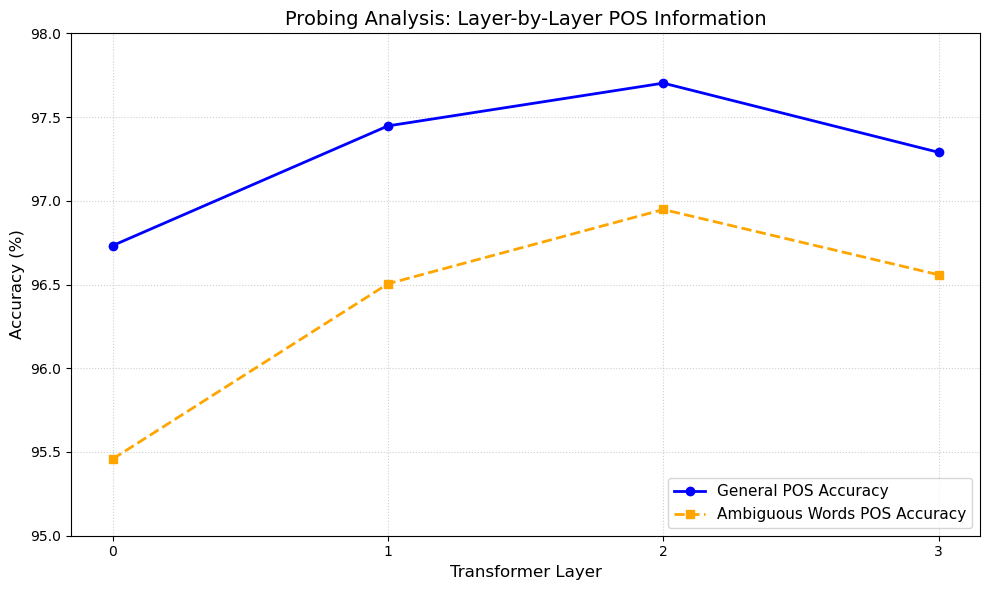

In [19]:
def plot_probing_results(num_layers, general_accuracies, ambiguous_accuracies):
    layers = list(range(num_layers))
    plt.figure(figsize=(10, 6))
    plt.plot(layers, general_accuracies, marker='o', linestyle='-', linewidth=2, 
             color='blue', label='General POS Accuracy')
    plt.plot(layers, ambiguous_accuracies, marker='s', linestyle='--', linewidth=2, 
             color='orange', label='Ambiguous Words POS Accuracy')
    
    plt.title('Probing Analysis: Layer-by-Layer POS Information', fontsize=14)
    plt.xlabel('Transformer Layer', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xticks(layers)
    plt.ylim(95.0, 98.0)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='lower right')
    plt.tight_layout()
    plt.show()


plot_probing_results(num_layers, all_general_acc, all_ambiguous_acc)